# 05 · Prices and total return

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/05_prices_and_total_return.ipynb)

**What you will learn**

- Which price table your plan has, and what one row of each means.
- Why returns must be computed from `total_return_index`, never from raw `close`, shown on a
  real 10-for-1 stock split.
- How much of a dividend payer's return is the dividend.
- Why one ticker is not one price series, and how to select the right one.
- The daily-bar helpers (`client.prices`, `client.total_return`, `client.price_panel`) on Pro
  and Institutional.

**Plan required:** none for sections 1 to 5 (free sample tier, month-end closes). Section 6
needs daily bars, included with Pro and Institutional; on the free tiers it explains what it
would run.

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Two price tables

| Table | Plans | One row per | Columns |
|---|---|---|---|
| `stock_price` | every plan | security and month-end (`observation = 'monthly'`), plus a close at each fiscal period end (`observation = 'period_end'`) | `close`, `total_return_index`, `div_cash`, `split_factor` |
| `stock_price_daily` | Pro, Institutional | security and trading day | open, high, low, close, volume, `total_return_index`, `is_primary_listing` |

Prices are licensed market data, not SEC filings, so their history starts in 1994 at the
earliest. A price is known at that day's close: point-in-time filtering uses `price_date`.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from valuein_sdk import ValueinClient

client = ValueinClient()
has_daily = "stock_price_daily" in client.tables()
print(f"plan '{client.plan}': daily bars {'available' if has_daily else 'not included'}")

monthly = client.run_query("""
    SELECT symbol, price_date, close, total_return_index
    FROM stock_price
    WHERE observation = 'monthly' AND symbol IN ('NVDA', 'KO', 'PG', 'PEP', 'JNJ', 'VZ')
    ORDER BY symbol, price_date
""")
monthly["price_date"] = pd.to_datetime(monthly["price_date"])
monthly.tail(3)


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


plan 'sample': daily bars not included


,symbol,price_date,close,total_return_index
411,VZ,2026-07-31,46.81,7.452595
412,VZ,2026-08-31,50.02,7.963657
413,VZ,2026-09-30,45.87,7.302938


## 2. A split breaks raw `close`

NVIDIA split its shares 10-for-1 in June 2024. One old share became ten new ones, so the quoted
price fell by about 90% while nobody lost money. `close` is the price as quoted that day (it
never changes after the fact, which makes it the right field for point-in-time price lookups).
`total_return_index` is adjusted for splits and reinvests dividends, so the ratio of two of its
values is the return an investor actually earned.

In [3]:
nvda = monthly[(monthly["symbol"] == "NVDA") & monthly["price_date"].between("2024-03-01", "2024-08-31")].copy()
nvda["return_from_close"] = nvda["close"].pct_change()
nvda["return_from_tri"] = nvda["total_return_index"].pct_change()
nvda[["price_date", "close", "total_return_index", "return_from_close", "return_from_tri"]].round(
    {"total_return_index": 1, "return_from_close": 3, "return_from_tri": 3}
)

,price_date,close,total_return_index,return_from_close,return_from_tri
176,2024-03-28,903.5601,1104.4,NaN,NaN
177,2024-04-30,864.0200,1056.1,-0.044,-0.044
178,2024-05-31,1096.3300,1340.0,0.269,0.269
179,2024-06-28,123.5400,1510.2,-0.887,0.127
180,2024-07-31,117.0200,1430.5,-0.053,-0.053
181,2024-08-30,119.3700,1459.2,0.020,0.020


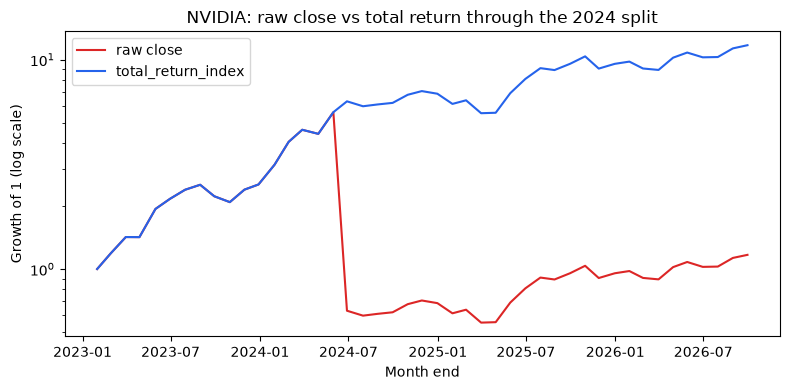

In [4]:
window = monthly[(monthly["symbol"] == "NVDA") & (monthly["price_date"] >= "2023-01-01")].set_index("price_date")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(window.index, window["close"] / window["close"].iloc[0], label="raw close", color="#dc2626")
ax.plot(window.index, window["total_return_index"] / window["total_return_index"].iloc[0],
        label="total_return_index", color="#2563eb")
ax.set_yscale("log")
ax.set_xlabel("Month end")
ax.set_ylabel("Growth of 1 (log scale)")
ax.set_title("NVIDIA: raw close vs total return through the 2024 split")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Dividends are part of the return

Price return ignores the cash a company pays out. For steady dividend payers the gap between
price return and total return is large. Never add `div_cash` on top of `total_return_index`:
the index already contains every dividend, so adding it again double counts.

In [5]:
payers = monthly[monthly["symbol"].isin(["KO", "PG", "PEP", "JNJ", "VZ"])].sort_values("price_date")
first, last = payers.groupby("symbol").first(), payers.groupby("symbol").last()
table = pd.DataFrame({
    "from": first["price_date"].dt.date,
    "to": last["price_date"].dt.date,
    "price_return": last["close"] / first["close"] - 1,
    "total_return": last["total_return_index"] / first["total_return_index"] - 1,
})
table["from_dividends"] = table["total_return"] - table["price_return"]
for column in ["price_return", "total_return", "from_dividends"]:
    table[column] = table[column].map("{:+.1%}".format)
table

,from,to,price_return,total_return,from_dividends
symbol,,,,,
JNJ,2021-01-29,2026-09-30,+62.3%,+90.1%,+27.8%
KO,2021-01-29,2026-09-30,+78.8%,+111.8%,+33.1%
PEP,2021-01-29,2026-09-30,-7.2%,+11.6%,+18.8%
PG,2021-01-29,2026-09-30,+13.3%,+30.5%,+17.2%
VZ,2021-01-29,2026-09-30,-16.2%,+17.5%,+33.7%


## 4. One ticker is not one price series

Prices are keyed by **security** (`security_id`), not by ticker or company, and each security's
`total_return_index` has its own starting level. Two traps follow:

- A company can carry more than one security (two share classes, or a ticker change recorded as a
  new listing). Grouping prices by `entity_id` alone interleaves them.
- A ticker can move to a different registrant. Exxon Mobil reorganized under a new holding
  company (a new CIK), and `XOM` now points at it. Filtering prices by `symbol = 'XOM'` splices
  two series with unrelated index levels, and a return computed across the join is meaningless.

Filter by `security_id` (or by `cik` plus `is_primary_listing` on daily bars), never by symbol.

In [6]:
client.run_query("""
    SELECT entity_id, security_id, symbol, min(price_date) AS first_bar, max(price_date) AS last_bar,
           arg_min(total_return_index, price_date) AS first_index_level
    FROM stock_price
    WHERE observation = 'monthly' AND symbol = 'XOM'
    GROUP BY ALL ORDER BY first_bar
""")

,entity_id,security_id,symbol,first_bar,last_bar,first_index_level
0,0000034088,234080,XOM,2021-01-29,2026-06-30,4.959694
1,0002115436,233983,XOM,2026-07-31,2026-09-30,1.140593


In [7]:
client.run_query("""
    SELECT entity_id, count(DISTINCT security_id) AS securities,
           string_agg(DISTINCT symbol, ', ' ORDER BY symbol) AS symbols
    FROM stock_price
    WHERE observation = 'monthly' AND price_date >= DATE '2025-01-01'
    GROUP BY entity_id
    HAVING count(DISTINCT security_id) > 1
    ORDER BY entity_id
""")

,entity_id,securities,symbols
0,0001415404,2,"ECHO, SATS"
1,0001474432,2,"P, PSTG"


On `stock_price_daily`, filter `is_primary_listing` to keep the issuer's main line. The SDK's
price helpers in section 6 already keep one bar per company and day.

## 5. The latest close, or the close on a date

`client.stock_price()` returns one row: the latest close known at the client's `as_of`, or the
last close on or before a given date. On the free tiers it reads the month-end table; on Pro and
Institutional it reads daily bars. The columns are the same either way.

In [8]:
pd.concat([client.stock_price("AAPL"), client.stock_price("AAPL", "2024-12-31")])[
    ["symbol", "price_date", "close", "total_return_index", "observation"]
]

,symbol,price_date,close,total_return_index,observation
0,AAPL,2026-09-30,333.02,1180.308525,monthly
0,AAPL,2024-12-31,250.42,881.158266,monthly


## 6. Daily bars (Pro and Institutional)

- `client.prices(tickers)` is a lazy query builder: `.between(start, end)`, `.last(n)`,
  `.fields(...)`, then `.to_pandas()` / `.to_arrow()` / `.to_polars()`.
- `client.total_return(ticker, start, end)` returns one number, splits and dividends included.
- `client.price_panel(tickers, start, end)` returns a date-by-ticker matrix of the total-return
  index, ready for `pct_change()`.

In [9]:
if has_daily:
    bars = client.prices(["NVDA", "KO"]).between("2024-01-01", "2024-12-31").to_pandas()
    print(bars.tail())
    print("NVDA 2024 total return:", f"{client.total_return('NVDA', '2024-01-01', '2024-12-31'):+.1%}")
    panel = client.price_panel(["NVDA", "KO"], "2024-01-01", "2024-12-31")
    print(panel.pct_change().describe())
else:
    print(f"Plan '{client.plan}' has no daily bars, so this cell does not call them.\n"
          "With a Pro or Institutional key it runs:\n"
          "  client.prices(['NVDA', 'KO']).between('2024-01-01', '2024-12-31').to_pandas()\n"
          "  client.total_return('NVDA', '2024-01-01', '2024-12-31')\n"
          "  client.price_panel(['NVDA', 'KO'], '2024-01-01', '2024-12-31')\n"
          "Plans and prices: https://valuein.biz/pricing")

Plan 'sample' has no daily bars, so this cell does not call them.
With a Pro or Institutional key it runs:
  client.prices(['NVDA', 'KO']).between('2024-01-01', '2024-12-31').to_pandas()
  client.total_return('NVDA', '2024-01-01', '2024-12-31')
  client.price_panel(['NVDA', 'KO'], '2024-01-01', '2024-12-31')
Plans and prices: https://valuein.biz/pricing


In [10]:
client.close()

## Rules to copy into your own code

1. Returns come from `total_return_index` (or the SDK helpers), never from `close`.
2. Never add `div_cash` to a total-return series.
3. Select prices by `security_id` (or `cik` plus `is_primary_listing` on daily bars), never by symbol.
4. Price history starts in 1994 at the earliest, later than the 1993 start of SEC fundamentals.

## Next steps

- **[06 · Restatements](06_restatements.ipynb)**: every number a later filing changed, and how
  the change was disclosed.
- Script version: [`python/price_total_return.py`](../python/price_total_return.py).